# ⚙️ Phase 2: Feature Engineering, Normalization & Multicollinearity Reduction

**Penelitian**: *Predicting Flaky Test in Cross-Project Scenario*

Notebook ini mengeksekusi **Phase 2** dari roadmap penelitian flaky test:
1. **Ratio Feature Engineering**: Mengubah fitur absolut menjadi rasio relatif (misal $\text{coverage\_ratio} = \frac{\text{numCoveredLines}}{\text{projectSourceLinesCovered} + 1}$) untuk menghilangkan ketergantungan pada ukuran proyek.
2. **Log Transformation**: Mengaplikasikan $\log(x+1)$ pada fitur numerik bernilai skewed tinggi (`ExecutionTime`, `testLength`, `numCoveredLines`, dll).
3. **Scaling & Normalization**: Menguji dan membandingkan dampak `StandardScaler` dan `RobustScaler` (Global vs Per-Project Scaling) dalam mengatasi *Domain Shift*.
4. **Multicollinearity Reduction**: Menganalisis korelasi 8 window `hIndex` dan mereduksi redundansi menggunakan *Feature Selection* & *PCA*.
5. **Ekspor Dataset Engineered**: Menyimpan matriks fitur ter-transformasi ke `data/engineered_test_features.csv`.

## 1. Import Library & Load Cleaned Dataset (Phase 1)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Path dataset Phase 1
data_path = "../data/cleaned_test_features.csv"
df = pd.read_csv(data_path)
print(f"Cleaned Dataset Shape: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Sisa Missing Values: {df.isnull().sum().sum()}")

Cleaned Dataset Shape: 22236 baris, 29 kolom
Sisa Missing Values: 0


## 2. Feature Engineering: Rasio Project-Agnostic

Fitur absolut (seperti `numCoveredLines` atau `projectSourceLinesCovered`) berbeda drastis nilainya antar proyek. Untuk membuat fitur yang *transferable* secara *cross-project*, kita membuat fitur rasio relatif:
- $\text{coverage\_ratio} = \frac{\text{numCoveredLines}}{\text{projectSourceLinesCovered} + 1}$
- $\text{assert\_density} = \frac{\text{numAsserts}}{\text{testLength} + 1}$
- $\text{class\_coverage\_ratio} = \frac{\text{numCoveredLines}}{\text{projectSourceClassesCovered} + 1}$

In [2]:
# Konstruksi Fitur Rasio
df['coverage_ratio'] = df['numCoveredLines'] / (df['projectSourceLinesCovered'] + 1)
df['assert_density'] = df['numAsserts'] / (df['testLength'] + 1)
df['class_coverage_ratio'] = df['numCoveredLines'] / (df['projectSourceClassesCovered'] + 1)

print("Fitur Rasio Berhasil Dibuat!")
print("Statistik Deskriptif Fitur Rasio:")
print(df[['coverage_ratio', 'assert_density', 'class_coverage_ratio']].describe())

Fitur Rasio Berhasil Dibuat!
Statistik Deskriptif Fitur Rasio:
       coverage_ratio  assert_density  class_coverage_ratio
count    22236.000000    22236.000000          22236.000000
mean         0.261167        0.113747              0.741651
std          0.249532        0.130440              1.096431
min          0.000000        0.000000              0.000000
25%          0.125000        0.000000              0.235294
50%          0.200000        0.095238              0.402453
75%          0.350000        0.181818              0.833333
max          8.000000        0.875000             24.500000


## 3. Log Transformation pada Fitur Skewed

Fitur eksekusi dan ukuran kode (`ExecutionTime`, `testLength`, `numCoveredLines`, dll) berdistribusi *long-tailed / right-skewed*. Transformasi $\log(x+1)$ memperkecil dampak outlier ekstrem dan menormalisasi distribusi.

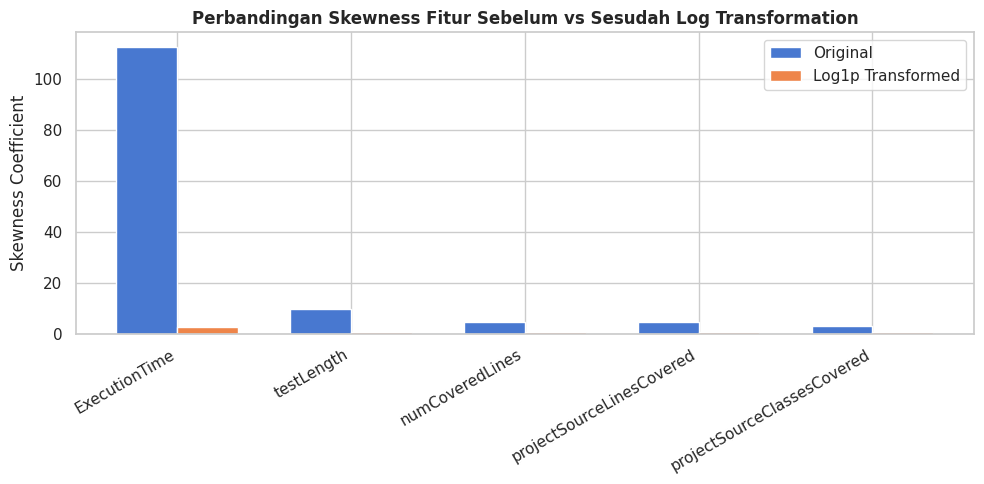

                Fitur Original  Skewness Original  Skewness Log1p
0                ExecutionTime         112.501549        2.817165
1                   testLength           9.796690        0.854473
2              numCoveredLines           4.626864        0.662534
3    projectSourceLinesCovered           4.720507        0.698668
4  projectSourceClassesCovered           3.120137        0.639506


In [3]:
skewed_cols = ['ExecutionTime', 'testLength', 'numCoveredLines', 'projectSourceLinesCovered', 'projectSourceClassesCovered']

# Evaluasi Skewness Sebelum & Sesudah Log Transformation
skew_before = df[skewed_cols].skew()

for col in skewed_cols:
    df[f'log_{col}'] = np.log1p(df[col])

log_cols = [f'log_{col}' for col in skewed_cols]
skew_after = df[log_cols].skew()

skew_df = pd.DataFrame({
    'Fitur Original': skewed_cols,
    'Skewness Original': skew_before.values,
    'Skewness Log1p': skew_after.values
})

plt.figure(figsize=(10, 5))
x = np.arange(len(skewed_cols))
width = 0.35
plt.bar(x - width/2, skew_df['Skewness Original'], width, label='Original')
plt.bar(x + width/2, skew_df['Skewness Log1p'], width, label='Log1p Transformed')
plt.xticks(x, skewed_cols, rotation=30, ha='right')
plt.ylabel('Skewness Coefficient')
plt.title('Perbandingan Skewness Fitur Sebelum vs Sesudah Log Transformation', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(skew_df)

## 4. Scaling Strategies & Domain Shift Mitigation

Membandingkan dampak `StandardScaler` (Z-score) vs `RobustScaler` (Median & IQR, tahan outlier) pada fitur numerik.

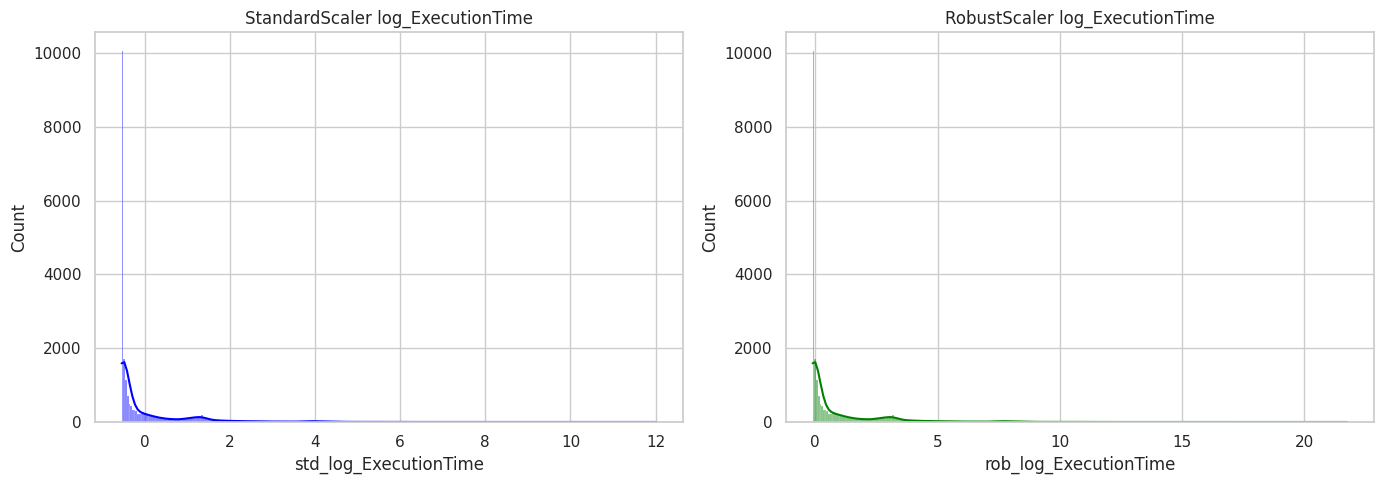

In [4]:
num_features_to_scale = log_cols + ['coverage_ratio', 'assert_density', 'class_coverage_ratio', 'num_third_party_libs']

scaler_std = StandardScaler()
scaler_rob = RobustScaler()

scaled_std_mat = scaler_std.fit_transform(df[num_features_to_scale])
scaled_rob_mat = scaler_rob.fit_transform(df[num_features_to_scale])

# Simpan hasil scaling ke DataFrame
for i, col in enumerate(num_features_to_scale):
    df[f'std_{col}'] = scaled_std_mat[:, i]
    df[f'rob_{col}'] = scaled_rob_mat[:, i]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['std_log_ExecutionTime'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('StandardScaler log_ExecutionTime')

sns.histplot(df['rob_log_ExecutionTime'], kde=True, ax=axes[1], color='green')
axes[1].set_title('RobustScaler log_ExecutionTime')
plt.tight_layout()
plt.show()

## 5. Multicollinearity Reduction pada Fitur Code Churn (`hIndex`)

8 window `hIndexModificationsPerCoveredLine_window*` mengukur modifikasi kode dalam commit terakhir (5, 10, 25, 50, 75, 100, 500, 10000).
Kita menerapkan **PCA (Principal Component Analysis)** untuk mereduksi 8 fitur churn ber-multikolinearitas menjadi kompresi komponen utama.

Explained Variance Ratio tiap PCA Component: [0.49825789 0.17215049 0.12455755]
Total Variance Explained oleh 3 Komponen: 79.50%


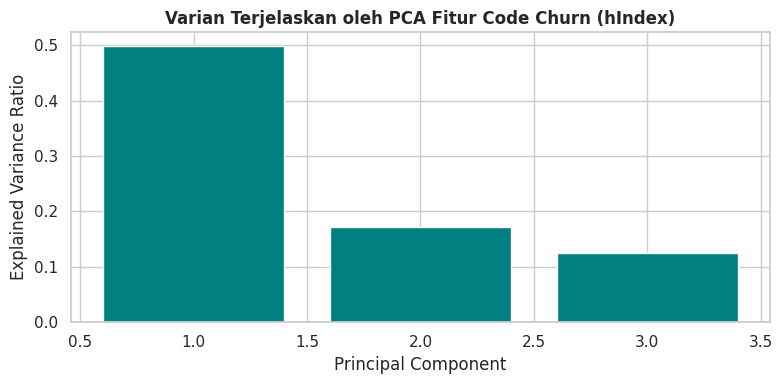

In [5]:
churn_cols = [c for c in df.columns if 'hIndex' in c and not c.startswith(('std_', 'rob_'))]

# Standardize churn columns before PCA
churn_scaled = StandardScaler().fit_transform(df[churn_cols])

pca = PCA(n_components=3)
churn_pca = pca.fit_transform(churn_scaled)

print("Explained Variance Ratio tiap PCA Component:", pca.explained_variance_ratio_)
print(f"Total Variance Explained oleh 3 Komponen: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

df['churn_pca_1'] = churn_pca[:, 0]
df['churn_pca_2'] = churn_pca[:, 1]
df['churn_pca_3'] = churn_pca[:, 2]

plt.figure(figsize=(8, 4))
plt.bar(range(1, 4), pca.explained_variance_ratio_, color='teal')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Varian Terjelaskan oleh PCA Fitur Code Churn (hIndex)', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Penyimpanan Dataset Engineered (Phase 2 Output)

In [6]:
output_path = "../data/engineered_test_features.csv"
df.to_csv(output_path, index=False)
print(f"✅ Dataset Engineered Phase 2 berhasil disimpan ke: {output_path}")
print(f"Ukuran dataset akhir: {df.shape[0]} baris, {df.shape[1]} kolom")

✅ Dataset Engineered Phase 2 berhasil disimpan ke: ../data/engineered_test_features.csv
Ukuran dataset akhir: 22236 baris, 58 kolom
